# Semana 13 — SARSA y Q-learning: control TD sin modelo

**Modelos de Decisión en el Tiempo — Aprendizaje por refuerzo tabular**

En esta sesión pasamos de la evaluación de políticas mediante Monte Carlo y TD(0) al **control**: el agente ya no solo estima valores, sino que aprende qué acción conviene tomar.

La diferencia central es:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma Q(s',a') - Q(s,a) \right]
$$

para **SARSA**, mientras que **Q-learning** utiliza:

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right].
$$

## Convenciones de programación

Usaremos únicamente:

- arreglos de NumPy;
- ciclos `for` y `while`;
- condicionales `if` y `else`;
- funciones sencillas;
- `np.argmax` para identificar la mejor acción.



## Importaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

## Herramienta común: acción $\varepsilon$-greedy

La función siguiente se reutiliza en los tres ejercicios. Recibe el número de acciones que son válidas en el estado actual.

In [2]:
def elegir_accion_epsilon_greedy(
    Q,
    estado,
    numero_acciones_validas,
    epsilon
):
    numero_aleatorio = np.random.random()

    if numero_aleatorio < epsilon:
        accion = np.random.randint(
            numero_acciones_validas
        )
    else:
        accion = 0
        mejor_valor = Q[estado, 0]

        for accion_posible in range(
            1,
            numero_acciones_validas
        ):
            valor = Q[
                estado,
                accion_posible
            ]

            if valor > mejor_valor:
                mejor_valor = valor
                accion = accion_posible

    return accion

---

# Ejercicio 1 — Control de inventario con SARSA

## Contexto

**AgroValle S.A.S.** gestiona semanalmente un fertilizante.

- Inventario máximo: 5 unidades.
- Demanda semanal: Poisson con media 2.
- Precio de venta: 4 por unidad.
- Costo de ordenar: 2 por unidad.
- Costo de almacenamiento: 1 por unidad sobrante.
- Acción: cantidad que se ordena al comienzo de la semana.

Interpretaremos el sistema como una **tarea continua descontada**. Cada bloque de 50 semanas es solamente un segmento de entrenamiento; el proceso no termina realmente después de la semana 50. Por eso SARSA conserva el término de continuación en el último paso del segmento.

## 1.1 Un solo paso del entorno

In [3]:
capacidad = 5
media_demanda = 2.0
precio_venta = 4
costo_orden = 2
costo_almacenamiento = 1

np.random.seed(42)

inventario_actual = 2
cantidad_ordenada = 1
inventario_disponible = (
    inventario_actual + cantidad_ordenada
)

demanda = np.random.poisson(
    media_demanda
)

if demanda > capacidad:
    demanda = capacidad

unidades_vendidas = min(
    inventario_disponible,
    demanda
)

inventario_siguiente = max(
    0,
    inventario_disponible - demanda
)

recompensa = (
    precio_venta * unidades_vendidas
    - costo_orden * cantidad_ordenada
    - costo_almacenamiento
      * inventario_siguiente
)

print("Inventario inicial:", inventario_actual)
print("Cantidad ordenada:", cantidad_ordenada)
print(
    "Inventario antes de la demanda:",
    inventario_disponible
)
print("Demanda:", demanda)
print("Unidades vendidas:", unidades_vendidas)
print(
    "Inventario siguiente:",
    inventario_siguiente
)
print("Recompensa:", recompensa)

Inventario inicial: 2
Cantidad ordenada: 1
Inventario antes de la demanda: 3
Demanda: 4
Unidades vendidas: 3
Inventario siguiente: 0
Recompensa: 10


## 1.2 Una actualización manual de SARSA

La tabla $Q$  tendrá una fila por estado y una columna por cantidad ordenada. Cuando el inventario es \(s\), solo son factibles las acciones:

$$
a=0,1,\ldots,5-s.
$$

In [4]:
numero_estados_inventario = capacidad + 1
numero_acciones_inventario = capacidad + 1

Q_demostracion = np.zeros(
    (
        numero_estados_inventario,
        numero_acciones_inventario
    )
)

alpha_inventario = 0.1
gamma_inventario = 0.95
epsilon_demostracion = 1.0

np.random.seed(42)

estado = 2
numero_acciones_validas = (
    capacidad - estado + 1
)

accion = elegir_accion_epsilon_greedy(
    Q_demostracion,
    estado,
    numero_acciones_validas,
    epsilon_demostracion
)

inventario_disponible = estado + accion

demanda = np.random.poisson(
    media_demanda
)

if demanda > capacidad:
    demanda = capacidad

vendido = min(
    inventario_disponible,
    demanda
)

estado_siguiente = max(
    0,
    inventario_disponible - demanda
)

recompensa = (
    precio_venta * vendido
    - costo_orden * accion
    - costo_almacenamiento
      * estado_siguiente
)

numero_acciones_siguientes = (
    capacidad - estado_siguiente + 1
)

accion_siguiente = (
    elegir_accion_epsilon_greedy(
        Q_demostracion,
        estado_siguiente,
        numero_acciones_siguientes,
        epsilon_demostracion
    )
)

objetivo_sarsa = (
    recompensa
    + gamma_inventario
      * Q_demostracion[
          estado_siguiente,
          accion_siguiente
      ]
)

error_td = (
    objetivo_sarsa
    - Q_demostracion[estado, accion]
)

Q_demostracion[estado, accion] = (
    Q_demostracion[estado, accion]
    + alpha_inventario * error_td
)

print("Estado:", estado)
print("Acción:", accion)
print("Recompensa:", recompensa)
print("Estado siguiente:", estado_siguiente)
print("Acción siguiente:", accion_siguiente)
print("Objetivo SARSA:", objetivo_sarsa)
print(
    "Nuevo Q(s,a):",
    Q_demostracion[estado, accion]
)

Estado: 2
Acción: 0
Recompensa: 8
Estado siguiente: 0
Acción siguiente: 2
Objetivo SARSA: 8.0
Nuevo Q(s,a): 0.8


## 1.3 Función del entorno

In [5]:
def paso_inventario(
    estado,
    accion
):
    inventario_disponible = (
        estado + accion
    )

    demanda = np.random.poisson(
        media_demanda
    )

    if demanda > capacidad:
        demanda = capacidad

    vendido = min(
        inventario_disponible,
        demanda
    )

    estado_siguiente = max(
        0,
        inventario_disponible - demanda
    )

    recompensa = (
        precio_venta * vendido
        - costo_orden * accion
        - costo_almacenamiento
          * estado_siguiente
    )

    return estado_siguiente, recompensa

## 1.4 Entrenamiento con SARSA

In [6]:
def entrenar_sarsa_inventario(
    numero_episodios,
    semanas_por_segmento,
    alpha,
    gamma,
    epsilon_inicial,
    epsilon_final,
    semilla
):
    np.random.seed(semilla)

    Q = np.zeros(
        (
            numero_estados_inventario,
            numero_acciones_inventario
        )
    )

    retornos = np.zeros(
        numero_episodios
    )

    reduccion_epsilon = (
        epsilon_inicial
        - epsilon_final
    ) / numero_episodios

    for episodio in range(
        numero_episodios
    ):
        epsilon = (
            epsilon_inicial
            - reduccion_epsilon * episodio
        )

        if epsilon < epsilon_final:
            epsilon = epsilon_final

        estado = capacidad // 2

        numero_acciones_validas = (
            capacidad - estado + 1
        )

        accion = (
            elegir_accion_epsilon_greedy(
                Q,
                estado,
                numero_acciones_validas,
                epsilon
            )
        )

        retorno = 0.0

        for semana in range(
            semanas_por_segmento
        ):
            estado_siguiente, recompensa = (
                paso_inventario(
                    estado,
                    accion
                )
            )

            retorno = (
                retorno
                + gamma**semana
                  * recompensa
            )

            numero_acciones_siguientes = (
                capacidad
                - estado_siguiente
                + 1
            )

            accion_siguiente = (
                elegir_accion_epsilon_greedy(
                    Q,
                    estado_siguiente,
                    numero_acciones_siguientes,
                    epsilon
                )
            )

            objetivo = (
                recompensa
                + gamma
                  * Q[
                      estado_siguiente,
                      accion_siguiente
                  ]
            )

            error_td = (
                objetivo
                - Q[estado, accion]
            )

            Q[estado, accion] = (
                Q[estado, accion]
                + alpha * error_td
            )

            estado = estado_siguiente
            accion = accion_siguiente

        retornos[episodio] = retorno

    return Q, retornos

In [7]:
Q_sarsa_inventario, retornos_sarsa_inventario = (
    entrenar_sarsa_inventario(
        numero_episodios=3000,
        semanas_por_segmento=50,
        alpha=0.1,
        gamma=gamma_inventario,
        epsilon_inicial=1.0,
        epsilon_final=0.01,
        semilla=42
    )
)

print(
    "Retorno medio de los últimos 100 episodios:",
    np.mean(
        retornos_sarsa_inventario[-100:]
    )
)

Retorno medio de los últimos 100 episodios: 44.420195857676674


### 🎨 Visualización proporcionada

Esta celda solo resume la curva en bloques de 100 episodios. No se evalúa la sintaxis de Matplotlib.

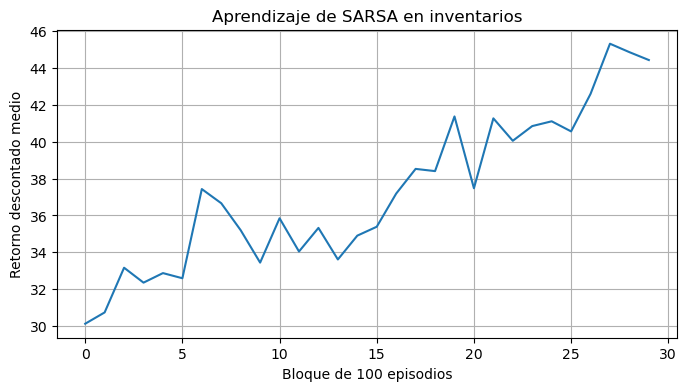

In [8]:
tamano_bloque = 100
numero_bloques = (
    len(retornos_sarsa_inventario)
    // tamano_bloque
)

promedios_bloques = np.zeros(
    numero_bloques
)

for bloque in range(numero_bloques):
    inicio = bloque * tamano_bloque
    fin = inicio + tamano_bloque

    promedios_bloques[bloque] = (
        np.mean(
            retornos_sarsa_inventario[
                inicio:fin
            ]
        )
    )

plt.figure(figsize=(8, 4))
plt.plot(promedios_bloques)
plt.xlabel("Bloque de 100 episodios")
plt.ylabel("Retorno descontado medio")
plt.title(
    "Aprendizaje de SARSA en inventarios"
)
plt.grid()
plt.show()

## 1.5 Política aprendida y heurística

In [9]:
politica_sarsa_inventario = np.zeros(
    numero_estados_inventario,
    dtype=int
)

politica_heuristica = np.zeros(
    numero_estados_inventario,
    dtype=int
)

for estado in range(
    numero_estados_inventario
):
    numero_acciones_validas = (
        capacidad - estado + 1
    )

    mejor_accion = 0
    mejor_valor = (
        Q_sarsa_inventario[estado, 0]
    )

    for accion in range(
        1,
        numero_acciones_validas
    ):
        valor = (
            Q_sarsa_inventario[
                estado,
                accion
            ]
        )

        if valor > mejor_valor:
            mejor_valor = valor
            mejor_accion = accion

    politica_sarsa_inventario[
        estado
    ] = mejor_accion

    if estado < 3:
        politica_heuristica[estado] = (
            3 - estado
        )
    else:
        politica_heuristica[estado] = 0

print("Estado | SARSA | Ordenar hasta 3")

for estado in range(
    numero_estados_inventario
):
    print(
        estado,
        "|",
        politica_sarsa_inventario[estado],
        "|",
        politica_heuristica[estado]
    )

Estado | SARSA | Ordenar hasta 3
0 | 2 | 3
1 | 1 | 2
2 | 0 | 1
3 | 0 | 0
4 | 0 | 0
5 | 0 | 0


## 1.6 Evaluación con escenarios comunes

Generaremos las mismas demandas para las dos políticas. Esto permite construir un intervalo de confianza para la diferencia:

\[
D_i=R_i^{	ext{SARSA}}
-R_i^{	ext{heurística}}.
\]

In [10]:
numero_evaluaciones = 500
semanas_evaluacion = 50

np.random.seed(2026)

demandas_evaluacion = np.zeros(
    (
        numero_evaluaciones,
        semanas_evaluacion
    ),
    dtype=int
)

for simulacion in range(
    numero_evaluaciones
):
    for semana in range(
        semanas_evaluacion
    ):
        demanda = np.random.poisson(
            media_demanda
        )

        if demanda > capacidad:
            demanda = capacidad

        demandas_evaluacion[
            simulacion,
            semana
        ] = demanda

In [11]:
def evaluar_politica_inventario(
    politica,
    demandas,
    gamma
):
    numero_simulaciones = (
        demandas.shape[0]
    )

    numero_semanas = (
        demandas.shape[1]
    )

    retornos = np.zeros(
        numero_simulaciones
    )

    for simulacion in range(
        numero_simulaciones
    ):
        estado = capacidad // 2
        retorno = 0.0

        for semana in range(
            numero_semanas
        ):
            accion = politica[estado]

            inventario_disponible = (
                estado + accion
            )

            demanda = demandas[
                simulacion,
                semana
            ]

            vendido = min(
                inventario_disponible,
                demanda
            )

            estado_siguiente = max(
                0,
                inventario_disponible
                - demanda
            )

            recompensa = (
                precio_venta * vendido
                - costo_orden * accion
                - costo_almacenamiento
                  * estado_siguiente
            )

            retorno = (
                retorno
                + gamma**semana
                  * recompensa
            )

            estado = estado_siguiente

        retornos[simulacion] = retorno

    return retornos

In [12]:
retornos_sarsa_eval = (
    evaluar_politica_inventario(
        politica_sarsa_inventario,
        demandas_evaluacion,
        gamma_inventario
    )
)

retornos_heuristica_eval = (
    evaluar_politica_inventario(
        politica_heuristica,
        demandas_evaluacion,
        gamma_inventario
    )
)

diferencias_inventario = (
    retornos_sarsa_eval
    - retornos_heuristica_eval
)

media_diferencia = np.mean(
    diferencias_inventario
)

error_diferencia = (
    1.96
    * np.std(
        diferencias_inventario,
        ddof=1
    )
    / np.sqrt(numero_evaluaciones)
)

print(
    "Retorno medio SARSA:",
    np.mean(retornos_sarsa_eval)
)

print(
    "Retorno medio heurística:",
    np.mean(retornos_heuristica_eval)
)

print(
    "Diferencia media:",
    media_diferencia
)

print(
    "IC 95% de la diferencia:",
    media_diferencia - error_diferencia,
    ",",
    media_diferencia + error_diferencia
)

Retorno medio SARSA: 46.34475556387468
Retorno medio heurística: 44.40668213949164
Diferencia media: 1.9380734243830366
IC 95% de la diferencia: 1.5380721689293628 , 2.3380746798367102


---

# Ejercicio 2 — Cliff Walking: SARSA frente a Q-learning

El entorno tiene 48 estados y cuatro acciones. Al entrar al precipicio, el agente recibe \(-100\) y regresa inmediatamente al inicio. Al llegar a la meta, el episodio termina.

## 2.1 Definición sencilla del entorno

In [13]:
numero_filas = 4
numero_columnas = 12

inicio_cliff = (3, 0)
meta_cliff = (3, 11)

desplazamientos = [
    (-1, 0),
    (1, 0),
    (0, -1),
    (0, 1)
]

numero_estados_cliff = (
    numero_filas * numero_columnas
)

numero_acciones_cliff = 4

In [14]:
def indice_celda(
    fila,
    columna
):
    indice = (
        fila * numero_columnas
        + columna
    )

    return indice


def es_precipicio(
    fila,
    columna
):
    resultado = False

    if fila == 3:
        if columna >= 1:
            if columna <= 10:
                resultado = True

    return resultado

## 2.2 Un paso desde el inicio

Tomar la acción Derecha conduce al precipicio, pero el siguiente estado real es nuevamente el inicio.

In [15]:
posicion = inicio_cliff
accion = 3

cambio_fila = (
    desplazamientos[accion][0]
)

cambio_columna = (
    desplazamientos[accion][1]
)

fila_nueva = (
    posicion[0] + cambio_fila
)

columna_nueva = (
    posicion[1] + cambio_columna
)

fila_nueva = max(
    0,
    min(numero_filas - 1, fila_nueva)
)

columna_nueva = max(
    0,
    min(
        numero_columnas - 1,
        columna_nueva
    )
)

if es_precipicio(
    fila_nueva,
    columna_nueva
):
    posicion_siguiente = inicio_cliff
    recompensa = -100
    termino = False
else:
    posicion_siguiente = (
        fila_nueva,
        columna_nueva
    )

    recompensa = -1

    termino = (
        posicion_siguiente == meta_cliff
    )

print("Posición inicial:", posicion)
print("Celda alcanzada:", (fila_nueva, columna_nueva))
print(
    "Posición siguiente real:",
    posicion_siguiente
)
print("Recompensa:", recompensa)

Posición inicial: (3, 0)
Celda alcanzada: (3, 1)
Posición siguiente real: (3, 0)
Recompensa: -100


## 2.3 Diferencia entre los objetivos

Después de caer, el siguiente estado es el inicio. SARSA usa la acción siguiente que realmente se tomará; Q-learning usa el máximo valor disponible.

In [16]:
Q_demostracion_cliff = np.zeros(
    (
        numero_estados_cliff,
        numero_acciones_cliff
    )
)

indice_inicio = indice_celda(
    inicio_cliff[0],
    inicio_cliff[1]
)

Q_demostracion_cliff[
    indice_inicio,
    0
] = 0.0

Q_demostracion_cliff[
    indice_inicio,
    1
] = -5.0

Q_demostracion_cliff[
    indice_inicio,
    2
] = -3.0

Q_demostracion_cliff[
    indice_inicio,
    3
] = -2.0

gamma_cliff = 1.0
accion_siguiente_real = 1

objetivo_sarsa = (
    recompensa
    + gamma_cliff
      * Q_demostracion_cliff[
          indice_inicio,
          accion_siguiente_real
      ]
)

mejor_valor_siguiente = np.max(
    Q_demostracion_cliff[
        indice_inicio,
        :
    ]
)

objetivo_q_learning = (
    recompensa
    + gamma_cliff
      * mejor_valor_siguiente
)

print("Objetivo SARSA:", objetivo_sarsa)
print(
    "Objetivo Q-learning:",
    objetivo_q_learning
)

Objetivo SARSA: -105.0
Objetivo Q-learning: -100.0


## 2.4 Función del entorno

In [17]:
def paso_cliff(
    posicion,
    accion
):
    cambio_fila = (
        desplazamientos[accion][0]
    )

    cambio_columna = (
        desplazamientos[accion][1]
    )

    fila_nueva = (
        posicion[0] + cambio_fila
    )

    columna_nueva = (
        posicion[1] + cambio_columna
    )

    fila_nueva = max(
        0,
        min(
            numero_filas - 1,
            fila_nueva
        )
    )

    columna_nueva = max(
        0,
        min(
            numero_columnas - 1,
            columna_nueva
        )
    )

    if es_precipicio(
        fila_nueva,
        columna_nueva
    ):
        posicion_siguiente = inicio_cliff
        recompensa = -100
        termino = False

    else:
        posicion_siguiente = (
            fila_nueva,
            columna_nueva
        )

        recompensa = -1

        termino = (
            posicion_siguiente
            == meta_cliff
        )

    return (
        posicion_siguiente,
        recompensa,
        termino
    )

## 2.5 Entrenamiento de Q-learning

In [18]:
def entrenar_q_learning_cliff(
    numero_episodios,
    alpha,
    gamma,
    epsilon,
    maximo_pasos,
    semilla
):
    np.random.seed(semilla)

    Q = np.zeros(
        (
            numero_estados_cliff,
            numero_acciones_cliff
        )
    )

    retornos = np.zeros(
        numero_episodios
    )

    for episodio in range(
        numero_episodios
    ):
        posicion = inicio_cliff

        estado = indice_celda(
            posicion[0],
            posicion[1]
        )

        retorno = 0.0

        for paso in range(
            maximo_pasos
        ):
            accion = (
                elegir_accion_epsilon_greedy(
                    Q,
                    estado,
                    numero_acciones_cliff,
                    epsilon
                )
            )

            posicion_siguiente, recompensa, termino = (
                paso_cliff(
                    posicion,
                    accion
                )
            )

            estado_siguiente = indice_celda(
                posicion_siguiente[0],
                posicion_siguiente[1]
            )

            retorno = retorno + recompensa

            if termino:
                objetivo = recompensa
            else:
                mejor_valor = np.max(
                    Q[
                        estado_siguiente,
                        :
                    ]
                )

                objetivo = (
                    recompensa
                    + gamma * mejor_valor
                )

            error_td = (
                objetivo
                - Q[estado, accion]
            )

            Q[estado, accion] = (
                Q[estado, accion]
                + alpha * error_td
            )

            posicion = posicion_siguiente
            estado = estado_siguiente

            if termino:
                break

        retornos[episodio] = retorno

    return Q, retornos

## 2.6 Entrenamiento de SARSA

In [19]:
def entrenar_sarsa_cliff(
    numero_episodios,
    alpha,
    gamma,
    epsilon,
    maximo_pasos,
    semilla
):
    np.random.seed(semilla)

    Q = np.zeros(
        (
            numero_estados_cliff,
            numero_acciones_cliff
        )
    )

    retornos = np.zeros(
        numero_episodios
    )

    for episodio in range(
        numero_episodios
    ):
        posicion = inicio_cliff

        estado = indice_celda(
            posicion[0],
            posicion[1]
        )

        accion = (
            elegir_accion_epsilon_greedy(
                Q,
                estado,
                numero_acciones_cliff,
                epsilon
            )
        )

        retorno = 0.0

        for paso in range(
            maximo_pasos
        ):
            posicion_siguiente, recompensa, termino = (
                paso_cliff(
                    posicion,
                    accion
                )
            )

            estado_siguiente = indice_celda(
                posicion_siguiente[0],
                posicion_siguiente[1]
            )

            retorno = retorno + recompensa

            if termino:
                objetivo = recompensa
            else:
                accion_siguiente = (
                    elegir_accion_epsilon_greedy(
                        Q,
                        estado_siguiente,
                        numero_acciones_cliff,
                        epsilon
                    )
                )

                objetivo = (
                    recompensa
                    + gamma
                      * Q[
                          estado_siguiente,
                          accion_siguiente
                      ]
                )

            error_td = (
                objetivo
                - Q[estado, accion]
            )

            Q[estado, accion] = (
                Q[estado, accion]
                + alpha * error_td
            )

            if termino:
                break

            posicion = posicion_siguiente
            estado = estado_siguiente
            accion = accion_siguiente

        retornos[episodio] = retorno

    return Q, retornos

In [20]:
Q_sarsa_cliff, retornos_sarsa_cliff = (
    entrenar_sarsa_cliff(
        numero_episodios=500,
        alpha=0.5,
        gamma=1.0,
        epsilon=0.1,
        maximo_pasos=1000,
        semilla=42
    )
)

Q_q_cliff, retornos_q_cliff = (
    entrenar_q_learning_cliff(
        numero_episodios=500,
        alpha=0.5,
        gamma=1.0,
        epsilon=0.1,
        maximo_pasos=1000,
        semilla=42
    )
)

print(
    "Retorno medio final SARSA:",
    np.mean(retornos_sarsa_cliff[-50:])
)

print(
    "Retorno medio final Q-learning:",
    np.mean(retornos_q_cliff[-50:])
)

Retorno medio final SARSA: -21.84
Retorno medio final Q-learning: -59.28


### 🎨 Visualización proporcionada

La gráfica muestra promedios por bloques de 20 episodios. No se evalúa la sintaxis de Matplotlib.

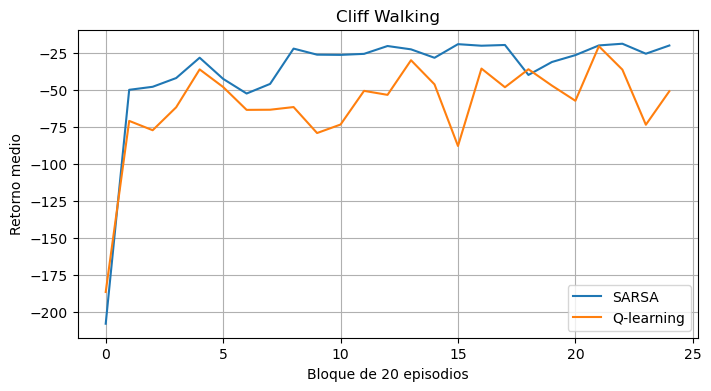

In [21]:
tamano_bloque_cliff = 20
numero_bloques_cliff = (
    len(retornos_sarsa_cliff)
    // tamano_bloque_cliff
)

promedios_sarsa_cliff = np.zeros(
    numero_bloques_cliff
)

promedios_q_cliff = np.zeros(
    numero_bloques_cliff
)

for bloque in range(
    numero_bloques_cliff
):
    inicio = (
        bloque * tamano_bloque_cliff
    )

    fin = (
        inicio + tamano_bloque_cliff
    )

    promedios_sarsa_cliff[bloque] = (
        np.mean(
            retornos_sarsa_cliff[
                inicio:fin
            ]
        )
    )

    promedios_q_cliff[bloque] = (
        np.mean(
            retornos_q_cliff[
                inicio:fin
            ]
        )
    )

plt.figure(figsize=(8, 4))
plt.plot(
    promedios_sarsa_cliff,
    label="SARSA"
)
plt.plot(
    promedios_q_cliff,
    label="Q-learning"
)
plt.xlabel("Bloque de 20 episodios")
plt.ylabel("Retorno medio")
plt.title("Cliff Walking")
plt.legend()
plt.grid()
plt.show()

## 2.7 Rutas greedy aprendidas

In [22]:
def construir_ruta_greedy_cliff(
    Q,
    maximo_pasos
):
    ruta = []

    posicion = inicio_cliff
    ruta.append(posicion)

    for paso in range(
        maximo_pasos
    ):
        estado = indice_celda(
            posicion[0],
            posicion[1]
        )

        accion = np.argmax(
            Q[estado, :]
        )

        posicion_siguiente, recompensa, termino = (
            paso_cliff(
                posicion,
                accion
            )
        )

        ruta.append(
            posicion_siguiente
        )

        posicion = posicion_siguiente

        if termino:
            break

    return ruta

In [23]:
ruta_sarsa = construir_ruta_greedy_cliff(
    Q_sarsa_cliff,
    maximo_pasos=100
)

ruta_q_learning = (
    construir_ruta_greedy_cliff(
        Q_q_cliff,
        maximo_pasos=100
    )
)

print("Ruta greedy de SARSA:")
print(ruta_sarsa)

print("Ruta greedy de Q-learning:")
print(ruta_q_learning)

Ruta greedy de SARSA:
[(3, 0), (2, 0), (1, 0), (1, 1), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11)]
Ruta greedy de Q-learning:
[(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)]


## 2.8 Estabilidad entre semillas

Usaremos 10 semillas en el núcleo del laboratorio. El estudiante puede aumentar el número a 30 como extensión. La banda que se reporta al final es un **intervalo de confianza para el retorno medio final**, no una banda de desviación estándar episodio por episodio.

In [24]:
numero_semillas_cliff = 10
numero_episodios_cliff = 500

medias_finales_sarsa = np.zeros(
    numero_semillas_cliff
)

medias_finales_q = np.zeros(
    numero_semillas_cliff
)

for semilla in range(
    numero_semillas_cliff
):
    Q_temporal, retornos_temporales = (
        entrenar_sarsa_cliff(
            numero_episodios=(
                numero_episodios_cliff
            ),
            alpha=0.5,
            gamma=1.0,
            epsilon=0.1,
            maximo_pasos=1000,
            semilla=semilla
        )
    )

    medias_finales_sarsa[semilla] = (
        np.mean(
            retornos_temporales[-50:]
        )
    )

    Q_temporal, retornos_temporales = (
        entrenar_q_learning_cliff(
            numero_episodios=(
                numero_episodios_cliff
            ),
            alpha=0.5,
            gamma=1.0,
            epsilon=0.1,
            maximo_pasos=1000,
            semilla=semilla
        )
    )

    medias_finales_q[semilla] = (
        np.mean(
            retornos_temporales[-50:]
        )
    )

media_sarsa_semillas = np.mean(
    medias_finales_sarsa
)

error_sarsa_semillas = (
    1.96
    * np.std(
        medias_finales_sarsa,
        ddof=1
    )
    / np.sqrt(numero_semillas_cliff)
)

media_q_semillas = np.mean(
    medias_finales_q
)

error_q_semillas = (
    1.96
    * np.std(
        medias_finales_q,
        ddof=1
    )
    / np.sqrt(numero_semillas_cliff)
)

print(
    "SARSA:",
    media_sarsa_semillas,
    "+/-",
    error_sarsa_semillas
)

print(
    "Q-learning:",
    media_q_semillas,
    "+/-",
    error_q_semillas
)

SARSA: -28.192 +/- 2.5059413991906863
Q-learning: -48.050000000000004 +/- 4.331497515127482


---

# Ejercicio 3 — Pricing dinámico con estado compuesto

## Contexto corregido

**HotelAndes S.A.S.** dispone de 10 habitaciones y tiene cinco noches para venderlas.

El agente debe descubrir cómo equilibrar:

- un precio alto, que genera más ingreso por venta;
- una mayor probabilidad de venta cuando el precio es bajo;
- el número de noches restantes;
- las habitaciones disponibles.

No suponemos de antemano que los precios deban subir o bajar con el tiempo. Esa estructura debe surgir del modelo.

El estado es \((d,h)\), donde \(d\) son las noches restantes y \(h\) las habitaciones disponibles.

## 3.1 Parámetros y un paso manual

In [25]:
numero_habitaciones = 10
numero_noches = 5

precios = [
    80,
    120,
    160,
    200,
    250
]

probabilidades_venta = [
    0.70,
    0.50,
    0.30,
    0.15,
    0.05
]

numero_acciones_pricing = len(
    precios
)

numero_estados_pricing = (
    (numero_noches + 1)
    * (numero_habitaciones + 1)
)

np.random.seed(42)

noches_restantes = 5
habitaciones_disponibles = 10
accion_precio = 2

precio = precios[accion_precio]

probabilidad_venta = (
    probabilidades_venta[
        accion_precio
    ]
)

demanda = np.random.binomial(
    habitaciones_disponibles,
    probabilidad_venta
)

ingreso = precio * demanda

habitaciones_siguientes = (
    habitaciones_disponibles
    - demanda
)

noches_siguientes = (
    noches_restantes - 1
)

termino = (
    noches_siguientes == 0
)

print(
    "Estado:",
    (
        noches_restantes,
        habitaciones_disponibles
    )
)

print("Precio:", precio)
print("Demanda:", demanda)
print("Ingreso:", ingreso)

print(
    "Estado siguiente:",
    (
        noches_siguientes,
        habitaciones_siguientes
    )
)

print("Terminó:", termino)

Estado: (5, 10)
Precio: 160
Demanda: 2
Ingreso: 320
Estado siguiente: (4, 8)
Terminó: False


## 3.2 Codificación y entorno

In [26]:
def indice_pricing(
    noches_restantes,
    habitaciones_disponibles
):
    indice = (
        noches_restantes
        * (numero_habitaciones + 1)
        + habitaciones_disponibles
    )

    return indice

In [27]:
def paso_pricing(
    noches_restantes,
    habitaciones_disponibles,
    accion_precio
):
    precio = precios[accion_precio]

    probabilidad_venta = (
        probabilidades_venta[
            accion_precio
        ]
    )

    demanda = np.random.binomial(
        habitaciones_disponibles,
        probabilidad_venta
    )

    ingreso = precio * demanda

    habitaciones_siguientes = (
        habitaciones_disponibles
        - demanda
    )

    noches_siguientes = (
        noches_restantes - 1
    )

    termino = (
        noches_siguientes == 0
    )

    return (
        noches_siguientes,
        habitaciones_siguientes,
        ingreso,
        termino
    )

## 3.3 SARSA para pricing

In [28]:
def entrenar_sarsa_pricing(
    numero_episodios,
    alpha,
    gamma,
    epsilon_inicial,
    epsilon_final,
    semilla
):
    np.random.seed(semilla)

    Q = np.zeros(
        (
            numero_estados_pricing,
            numero_acciones_pricing
        )
    )

    retornos = np.zeros(
        numero_episodios
    )

    reduccion_epsilon = (
        epsilon_inicial
        - epsilon_final
    ) / numero_episodios

    for episodio in range(
        numero_episodios
    ):
        epsilon = (
            epsilon_inicial
            - reduccion_epsilon * episodio
        )

        if epsilon < epsilon_final:
            epsilon = epsilon_final

        noches = numero_noches
        habitaciones = numero_habitaciones

        estado = indice_pricing(
            noches,
            habitaciones
        )

        accion = (
            elegir_accion_epsilon_greedy(
                Q,
                estado,
                numero_acciones_pricing,
                epsilon
            )
        )

        retorno = 0.0

        while noches > 0:
            (
                noches_siguientes,
                habitaciones_siguientes,
                recompensa,
                termino
            ) = paso_pricing(
                noches,
                habitaciones,
                accion
            )

            retorno = retorno + recompensa

            estado_siguiente = indice_pricing(
                noches_siguientes,
                habitaciones_siguientes
            )

            if termino:
                objetivo = recompensa
            else:
                accion_siguiente = (
                    elegir_accion_epsilon_greedy(
                        Q,
                        estado_siguiente,
                        numero_acciones_pricing,
                        epsilon
                    )
                )

                objetivo = (
                    recompensa
                    + gamma
                      * Q[
                          estado_siguiente,
                          accion_siguiente
                      ]
                )

            error_td = (
                objetivo
                - Q[estado, accion]
            )

            Q[estado, accion] = (
                Q[estado, accion]
                + alpha * error_td
            )

            if termino:
                break

            noches = noches_siguientes
            habitaciones = (
                habitaciones_siguientes
            )

            estado = estado_siguiente
            accion = accion_siguiente

        retornos[episodio] = retorno

    return Q, retornos

## 3.4 Q-learning para pricing

In [29]:
def entrenar_q_learning_pricing(
    numero_episodios,
    alpha,
    gamma,
    epsilon_inicial,
    epsilon_final,
    semilla
):
    np.random.seed(semilla)

    Q = np.zeros(
        (
            numero_estados_pricing,
            numero_acciones_pricing
        )
    )

    retornos = np.zeros(
        numero_episodios
    )

    reduccion_epsilon = (
        epsilon_inicial
        - epsilon_final
    ) / numero_episodios

    for episodio in range(
        numero_episodios
    ):
        epsilon = (
            epsilon_inicial
            - reduccion_epsilon * episodio
        )

        if epsilon < epsilon_final:
            epsilon = epsilon_final

        noches = numero_noches
        habitaciones = numero_habitaciones

        retorno = 0.0

        while noches > 0:
            estado = indice_pricing(
                noches,
                habitaciones
            )

            accion = (
                elegir_accion_epsilon_greedy(
                    Q,
                    estado,
                    numero_acciones_pricing,
                    epsilon
                )
            )

            (
                noches_siguientes,
                habitaciones_siguientes,
                recompensa,
                termino
            ) = paso_pricing(
                noches,
                habitaciones,
                accion
            )

            retorno = retorno + recompensa

            estado_siguiente = indice_pricing(
                noches_siguientes,
                habitaciones_siguientes
            )

            if termino:
                objetivo = recompensa
            else:
                mejor_valor = np.max(
                    Q[
                        estado_siguiente,
                        :
                    ]
                )

                objetivo = (
                    recompensa
                    + gamma * mejor_valor
                )

            error_td = (
                objetivo
                - Q[estado, accion]
            )

            Q[estado, accion] = (
                Q[estado, accion]
                + alpha * error_td
            )

            noches = noches_siguientes
            habitaciones = (
                habitaciones_siguientes
            )

            if termino:
                break

        retornos[episodio] = retorno

    return Q, retornos

In [30]:
Q_sarsa_pricing, retornos_sarsa_pricing = (
    entrenar_sarsa_pricing(
        numero_episodios=5000,
        alpha=0.1,
        gamma=1.0,
        epsilon_inicial=1.0,
        epsilon_final=0.01,
        semilla=42
    )
)

Q_q_pricing, retornos_q_pricing = (
    entrenar_q_learning_pricing(
        numero_episodios=5000,
        alpha=0.1,
        gamma=1.0,
        epsilon_inicial=1.0,
        epsilon_final=0.01,
        semilla=42
    )
)

print(
    "Ingreso medio final SARSA:",
    np.mean(
        retornos_sarsa_pricing[-200:]
    )
)

print(
    "Ingreso medio final Q-learning:",
    np.mean(
        retornos_q_pricing[-200:]
    )
)

Ingreso medio final SARSA: 1337.8
Ingreso medio final Q-learning: 1343.8


## 3.5 Benchmark exacto mediante backward induction

El agente no conoce la curva de demanda durante el aprendizaje. Nosotros sí podemos usarla después para construir un benchmark exacto y verificar qué tan cerca quedaron las políticas aprendidas.

> **Código proporcionado:** la fórmula binomial y el cálculo exacto se incluyen como referencia. El objetivo central sigue siendo comparar SARSA y Q-learning.

In [31]:
valor_exacto_pricing = np.zeros(
    (
        numero_noches + 1,
        numero_habitaciones + 1
    )
)

politica_exacta_pricing = -np.ones(
    (
        numero_noches + 1,
        numero_habitaciones + 1
    ),
    dtype=int
)

for noches in range(
    1,
    numero_noches + 1
):
    for habitaciones in range(
        numero_habitaciones + 1
    ):
        if habitaciones == 0:
            valor_exacto_pricing[
                noches,
                habitaciones
            ] = 0.0

        else:
            mejor_valor = -1000000.0
            mejor_accion = 0

            for accion in range(
                numero_acciones_pricing
            ):
                precio = precios[accion]

                probabilidad_venta = (
                    probabilidades_venta[
                        accion
                    ]
                )

                valor_accion = 0.0

                for demanda in range(
                    habitaciones + 1
                ):
                    probabilidad_demanda = (
                        comb(
                            habitaciones,
                            demanda
                        )
                        * probabilidad_venta**demanda
                        * (
                            1
                            - probabilidad_venta
                        )**(
                            habitaciones
                            - demanda
                        )
                    )

                    ingreso = (
                        precio * demanda
                    )

                    habitaciones_siguientes = (
                        habitaciones
                        - demanda
                    )

                    valor_accion = (
                        valor_accion
                        + probabilidad_demanda
                          * (
                              ingreso
                              + valor_exacto_pricing[
                                  noches - 1,
                                  habitaciones_siguientes
                              ]
                          )
                    )

                if valor_accion > mejor_valor:
                    mejor_valor = valor_accion
                    mejor_accion = accion

            valor_exacto_pricing[
                noches,
                habitaciones
            ] = mejor_valor

            politica_exacta_pricing[
                noches,
                habitaciones
            ] = mejor_accion

print(
    "Valor exacto desde (5,10):",
    valor_exacto_pricing[5, 10]
)

print(
    "Precio exacto inicial:",
    precios[
        politica_exacta_pricing[5, 10]
    ]
)

Valor exacto desde (5,10): 1368.449999999999
Precio exacto inicial: 200


## 3.6 Políticas aprendidas

Para \(h=0\) no existe una decisión relevante; se mostrará un guion.

In [32]:
politica_sarsa_pricing = -np.ones(
    (
        numero_noches + 1,
        numero_habitaciones + 1
    ),
    dtype=int
)

politica_q_pricing = -np.ones(
    (
        numero_noches + 1,
        numero_habitaciones + 1
    ),
    dtype=int
)

for noches in range(
    1,
    numero_noches + 1
):
    for habitaciones in range(
        1,
        numero_habitaciones + 1
    ):
        estado = indice_pricing(
            noches,
            habitaciones
        )

        politica_sarsa_pricing[
            noches,
            habitaciones
        ] = np.argmax(
            Q_sarsa_pricing[estado, :]
        )

        politica_q_pricing[
            noches,
            habitaciones
        ] = np.argmax(
            Q_q_pricing[estado, :]
        )

print(
    "Noches | Habitaciones | Exacta | SARSA | Q-learning"
)

for noches in range(
    numero_noches,
    0,
    -1
):
    for habitaciones in range(
        1,
        numero_habitaciones + 1
    ):
        accion_exacta = (
            politica_exacta_pricing[
                noches,
                habitaciones
            ]
        )

        accion_sarsa = (
            politica_sarsa_pricing[
                noches,
                habitaciones
            ]
        )

        accion_q = (
            politica_q_pricing[
                noches,
                habitaciones
            ]
        )

        print(
            noches,
            "|",
            habitaciones,
            "|",
            precios[accion_exacta],
            "|",
            precios[accion_sarsa],
            "|",
            precios[accion_q]
        )

Noches | Habitaciones | Exacta | SARSA | Q-learning
5 | 1 | 200 | 80 | 80
5 | 2 | 200 | 80 | 80
5 | 3 | 200 | 80 | 80
5 | 4 | 200 | 80 | 80
5 | 5 | 200 | 80 | 80
5 | 6 | 200 | 80 | 80
5 | 7 | 200 | 80 | 80
5 | 8 | 200 | 80 | 80
5 | 9 | 200 | 80 | 80
5 | 10 | 200 | 160 | 160
4 | 1 | 160 | 120 | 120
4 | 2 | 160 | 250 | 250
4 | 3 | 160 | 160 | 160
4 | 4 | 160 | 160 | 160
4 | 5 | 160 | 200 | 160
4 | 6 | 160 | 160 | 160
4 | 7 | 160 | 160 | 200
4 | 8 | 160 | 160 | 160
4 | 9 | 160 | 120 | 160
4 | 10 | 160 | 120 | 160
3 | 1 | 160 | 250 | 250
3 | 2 | 160 | 160 | 120
3 | 3 | 160 | 120 | 160
3 | 4 | 160 | 160 | 120
3 | 5 | 160 | 160 | 120
3 | 6 | 160 | 160 | 160
3 | 7 | 160 | 120 | 160
3 | 8 | 160 | 120 | 120
3 | 9 | 160 | 160 | 160
3 | 10 | 160 | 120 | 160
2 | 1 | 120 | 120 | 120
2 | 2 | 120 | 120 | 160
2 | 3 | 120 | 120 | 120
2 | 4 | 120 | 120 | 120
2 | 5 | 120 | 160 | 120
2 | 6 | 120 | 120 | 120
2 | 7 | 120 | 80 | 80
2 | 8 | 120 | 160 | 160
2 | 9 | 120 | 120 | 120
2 | 10 | 120 | 120 | 120
1 | 

### 🎨 Visualización proporcionada

La siguiente celda muestra únicamente la política exacta. No se evalúa la sintaxis de Matplotlib.

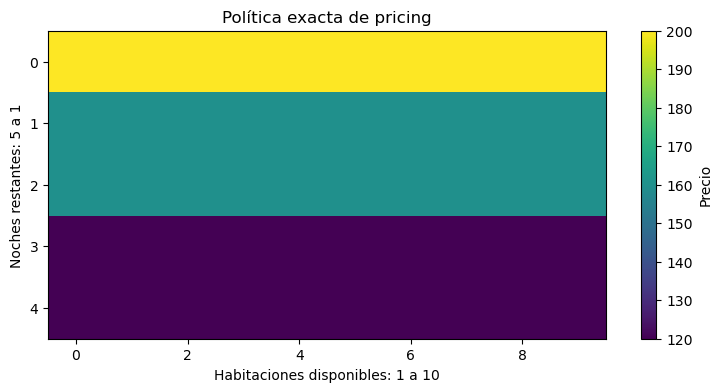

In [33]:
matriz_precios_exactos = np.zeros(
    (
        numero_noches,
        numero_habitaciones
    )
)

for fila in range(
    numero_noches
):
    noches = (
        numero_noches - fila
    )

    for columna in range(
        numero_habitaciones
    ):
        habitaciones = columna + 1

        accion = (
            politica_exacta_pricing[
                noches,
                habitaciones
            ]
        )

        matriz_precios_exactos[
            fila,
            columna
        ] = precios[accion]

plt.figure(figsize=(9, 4))
plt.imshow(
    matriz_precios_exactos,
    aspect="auto"
)
plt.colorbar(
    label="Precio"
)
plt.xlabel("Habitaciones disponibles: 1 a 10")
plt.ylabel("Noches restantes: 5 a 1")
plt.title("Política exacta de pricing")
plt.show()

## 3.7 Sensibilidad a la tasa de aprendizaje

Para cada \(lpha\):

1. entrenamos varias semillas;
2. evaluamos la política greedy, sin exploración;
3. usamos los mismos escenarios aleatorios para todas las políticas de evaluación.

El núcleo usa cinco semillas para conservar un tiempo de ejecución razonable.

In [ ]:
def construir_politica_pricing(
    Q
):
    politica = -np.ones(
        (
            numero_noches + 1,
            numero_habitaciones + 1
        ),
        dtype=int
    )

    for noches in range(
        1,
        numero_noches + 1
    ):
        for habitaciones in range(
            1,
            numero_habitaciones + 1
        ):
            estado = indice_pricing(
                noches,
                habitaciones
            )

            politica[
                noches,
                habitaciones
            ] = np.argmax(
                Q[estado, :]
            )

    return politica

In [ ]:
def evaluar_politica_pricing_comun(
    politica,
    uniformes
):
    numero_simulaciones = (
        uniformes.shape[0]
    )

    ingresos = np.zeros(
        numero_simulaciones
    )

    for simulacion in range(
        numero_simulaciones
    ):
        noches = numero_noches
        habitaciones = (
            numero_habitaciones
        )

        ingreso_total = 0.0

        while noches > 0:
            if habitaciones == 0:
                accion = 0
            else:
                accion = politica[
                    noches,
                    habitaciones
                ]

            precio = precios[accion]

            probabilidad_venta = (
                probabilidades_venta[
                    accion
                ]
            )

            indice_noche = (
                numero_noches - noches
            )

            demanda = 0

            for habitacion in range(
                habitaciones
            ):
                numero_aleatorio = (
                    uniformes[
                        simulacion,
                        indice_noche,
                        habitacion
                    ]
                )

                if (
                    numero_aleatorio
                    < probabilidad_venta
                ):
                    demanda = demanda + 1

            ingreso_total = (
                ingreso_total
                + precio * demanda
            )

            habitaciones = (
                habitaciones - demanda
            )

            noches = noches - 1

        ingresos[simulacion] = (
            ingreso_total
        )

    return ingresos

In [ ]:
valores_alpha = [
    0.05,
    0.1,
    0.2,
    0.5
]

numero_semillas_alpha = 5
numero_evaluaciones_pricing = 300

np.random.seed(2026)

uniformes_pricing = np.random.random(
    (
        numero_evaluaciones_pricing,
        numero_noches,
        numero_habitaciones
    )
)

medias_sarsa_alpha = np.zeros(
    (
        len(valores_alpha),
        numero_semillas_alpha
    )
)

medias_q_alpha = np.zeros(
    (
        len(valores_alpha),
        numero_semillas_alpha
    )
)

for indice_alpha in range(
    len(valores_alpha)
):
    alpha = valores_alpha[
        indice_alpha
    ]

    for semilla in range(
        numero_semillas_alpha
    ):
        Q_temporal, retornos_temporales = (
            entrenar_sarsa_pricing(
                numero_episodios=2500,
                alpha=alpha,
                gamma=1.0,
                epsilon_inicial=1.0,
                epsilon_final=0.01,
                semilla=semilla
            )
        )

        politica_temporal = (
            construir_politica_pricing(
                Q_temporal
            )
        )

        ingresos_temporales = (
            evaluar_politica_pricing_comun(
                politica_temporal,
                uniformes_pricing
            )
        )

        medias_sarsa_alpha[
            indice_alpha,
            semilla
        ] = np.mean(
            ingresos_temporales
        )

        Q_temporal, retornos_temporales = (
            entrenar_q_learning_pricing(
                numero_episodios=2500,
                alpha=alpha,
                gamma=1.0,
                epsilon_inicial=1.0,
                epsilon_final=0.01,
                semilla=semilla
            )
        )

        politica_temporal = (
            construir_politica_pricing(
                Q_temporal
            )
        )

        ingresos_temporales = (
            evaluar_politica_pricing_comun(
                politica_temporal,
                uniformes_pricing
            )
        )

        medias_q_alpha[
            indice_alpha,
            semilla
        ] = np.mean(
            ingresos_temporales
        )

print("Alpha | SARSA +/- IC | Q-learning +/- IC")

for indice_alpha in range(
    len(valores_alpha)
):
    media_sarsa = np.mean(
        medias_sarsa_alpha[
            indice_alpha,
            :
        ]
    )

    error_sarsa = (
        1.96
        * np.std(
            medias_sarsa_alpha[
                indice_alpha,
                :
            ],
            ddof=1
        )
        / np.sqrt(
            numero_semillas_alpha
        )
    )

    media_q = np.mean(
        medias_q_alpha[
            indice_alpha,
            :
        ]
    )

    error_q = (
        1.96
        * np.std(
            medias_q_alpha[
                indice_alpha,
                :
            ],
            ddof=1
        )
        / np.sqrt(
            numero_semillas_alpha
        )
    )

    print(
        valores_alpha[indice_alpha],
        "|",
        media_sarsa,
        "+/-",
        error_sarsa,
        "|",
        media_q,
        "+/-",
        error_q
    )

## 3.8 Evaluación final frente al benchmark exacto y al precio fijo

El intervalo se calcula sobre diferencias emparejadas generadas con los mismos números aleatorios.

In [ ]:
politica_precio_fijo = -np.ones(
    (
        numero_noches + 1,
        numero_habitaciones + 1
    ),
    dtype=int
)

for noches in range(
    1,
    numero_noches + 1
):
    for habitaciones in range(
        1,
        numero_habitaciones + 1
    ):
        politica_precio_fijo[
            noches,
            habitaciones
        ] = 2

In [ ]:
ingresos_exactos = (
    evaluar_politica_pricing_comun(
        politica_exacta_pricing,
        uniformes_pricing
    )
)

ingresos_sarsa = (
    evaluar_politica_pricing_comun(
        politica_sarsa_pricing,
        uniformes_pricing
    )
)

ingresos_q = (
    evaluar_politica_pricing_comun(
        politica_q_pricing,
        uniformes_pricing
    )
)

ingresos_fijos = (
    evaluar_politica_pricing_comun(
        politica_precio_fijo,
        uniformes_pricing
    )
)

print(
    "Ingreso medio exacto:",
    np.mean(ingresos_exactos)
)

print(
    "Ingreso medio SARSA:",
    np.mean(ingresos_sarsa)
)

print(
    "Ingreso medio Q-learning:",
    np.mean(ingresos_q)
)

print(
    "Ingreso medio precio fijo:",
    np.mean(ingresos_fijos)
)

diferencia_sarsa = (
    ingresos_sarsa - ingresos_exactos
)

diferencia_q = (
    ingresos_q - ingresos_exactos
)

error_sarsa = (
    1.96
    * np.std(
        diferencia_sarsa,
        ddof=1
    )
    / np.sqrt(
        numero_evaluaciones_pricing
    )
)

error_q = (
    1.96
    * np.std(
        diferencia_q,
        ddof=1
    )
    / np.sqrt(
        numero_evaluaciones_pricing
    )
)

print(
    "Diferencia SARSA - exacta:",
    np.mean(diferencia_sarsa),
    "+/-",
    error_sarsa
)

print(
    "Diferencia Q-learning - exacta:",
    np.mean(diferencia_q),
    "+/-",
    error_q
)

---

# Ejercicio abierto — Mantenimiento preventivo

## Entorno corregido

Los estados decisionales son:

\[
s\in\{1,2,3,4\}.
\]

La falla no es un estado en el que se tome una decisión, sino un **evento**:

- Si se elige **Operar**, la máquina empeora con probabilidad 0.6 y permanece igual con probabilidad 0.4.
- Si está en \(s=4\) y ocurre el deterioro, se produce una falla, se recibe \(-30\) y la máquina se reinicia en \(s=1\).
- Si no hay falla, Operar genera \(12-2s\).
- Elegir **Mantener** genera \(-10\) y lleva siempre a \(s=1\).

## Tareas obligatorias

1. Implementar `paso_excavadora(estado, accion)`.
2. Entrenar SARSA y Q-learning.
3. Comparar las políticas aprendidas.
4. Analizar \(\gamma\in\{0.5,0.9,0.95,0.99\}\).
5. Evaluar con varias semillas.

## Ampliación opcional

Double Q-learning puede desarrollarse como profundización después de dominar SARSA y Q-learning. No forma parte del núcleo obligatorio.

## Verificación manual

In [ ]:
np.random.seed(7)

estado = 3
accion = 0

recompensa_base = (
    12 - 2 * estado
)

numero_aleatorio = np.random.random()

if numero_aleatorio < 0.6:
    estado_antes_reinicio = (
        estado + 1
    )
else:
    estado_antes_reinicio = estado

if estado_antes_reinicio == 5:
    recompensa_final = -30
    estado_siguiente = 1
else:
    recompensa_final = recompensa_base
    estado_siguiente = (
        estado_antes_reinicio
    )

print("Estado actual:", estado)
print("Acción: Operar")
print(
    "Estado antes de revisar falla:",
    estado_antes_reinicio
)
print(
    "Recompensa final:",
    recompensa_final
)
print(
    "Estado siguiente:",
    estado_siguiente
)

## Prompt guiado para una IA

```text
Implementa un ejercicio de aprendizaje por refuerzo tabular en Python usando
solo numpy, arreglos, ciclos, condicionales y funciones sencillas.

No uses clases, defaultdict, diccionarios para Q, comprensiones, zip,
enumerate, lambda, expresiones condicionales en una línea, np.convolve,
plt.subplots ni formatos avanzados de impresión.

ENTORNO
- Estados decisionales: 1, 2, 3 y 4.
- Acciones: 0 Operar y 1 Mantener.
- Mantener: recompensa -10 y siguiente estado 1.
- Operar: recompensa base 12-2s.
- Al operar, el desgaste aumenta con probabilidad 0.6 y permanece igual con 0.4.
- Si se opera desde 4 y ocurre deterioro, hay falla: recompensa -30 y reinicio en 1.
- La tarea es continua descontada.

IMPLEMENTAR
1. Un paso manual desde estado 3 y acción Operar.
2. Función paso_excavadora(estado, accion).
3. SARSA y Q-learning con tablas Q de NumPy.
4. Epsilon-greedy decreciente.
5. Comparación de las políticas aprendidas.
6. Sensibilidad a gamma en 0.5, 0.9, 0.95 y 0.99.
7. Evaluación con 10 semillas y un intervalo de confianza.

Double Q-learning debe quedar como ampliación opcional.
```

In [ ]:
# Pegue aquí la solución desarrollada y compárela
# con la verificación manual anterior.

---

Universidad de los Andes — Departamento de Ingeniería Industrial  
Modelos de Decisión en el Tiempo — Semana 13